# Phase 4 — Baseline Evaluation
Audit the trained baseline with class-level test metrics and a confusion matrix.

In [1]:
from pathlib import Path
import json, torch, pandas as pd
from torch.utils.data import DataLoader
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
root = Path.cwd(); df = pd.read_csv(root / 'phase2_clean_splits.csv')
df = df[df.split.eq('test')].copy(); df['target'] = df.label.map({'OK':0,'Defective':1})
tf = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize([.485,.456,.406],[.229,.224,.225])])
class TestDS(torch.utils.data.Dataset):
    def __len__(self): return len(df)
    def __getitem__(self,i): return tf(Image.open(df.iloc[i].path).convert('RGB')), int(df.iloc[i].target)
loader = DataLoader(TestDS(), batch_size=64, shuffle=False); print(f'Test images: {len(df):,}')

Test images: 1,093


In [3]:
model = models.mobilenet_v2(weights=None); model.classifier[1] = torch.nn.Linear(model.last_channel, 2)
model.load_state_dict(torch.load(root / 'phase3_mobilenetv2_head_baseline.pt', map_location='cpu')); model.eval()
truth, pred = [], []
with torch.no_grad():
    for x,y in loader: truth += y.tolist(); pred += model(x).argmax(1).tolist()
print(classification_report(truth, pred, target_names=['OK','Defective'], digits=4))

              precision    recall  f1-score   support

          OK     0.8822    0.9913    0.9336       461
   Defective     0.9930    0.9035    0.9461       632

    accuracy                         0.9405      1093
   macro avg     0.9376    0.9474    0.9399      1093
weighted avg     0.9463    0.9405    0.9409      1093



[[457   4]
 [ 61 571]]


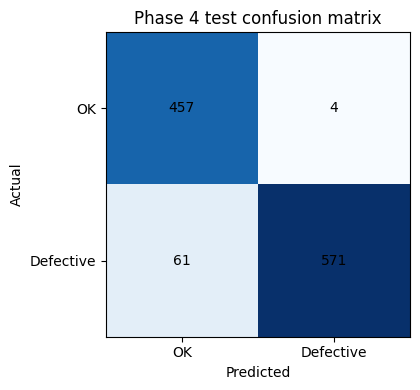

Phase 4 evaluation started; no additional training was run.


In [4]:
cm = confusion_matrix(truth, pred); print(cm)
fig, ax = plt.subplots(figsize=(5,4)); ax.imshow(cm, cmap='Blues')
ax.set(xticks=[0,1], yticks=[0,1], xticklabels=['OK','Defective'], yticklabels=['OK','Defective'], xlabel='Predicted', ylabel='Actual', title='Phase 4 test confusion matrix')
for (i,j), value in __import__('numpy').ndenumerate(cm): ax.text(j,i,str(value),ha='center',va='center')
plt.tight_layout(); plt.savefig('phase4_confusion_matrix.png',dpi=160); plt.show()
print('Phase 4 evaluation started; no additional training was run.')